# Check age proportions in SSNAP data

The SSNAP data contains information on stroke admissions and the ages of the patients. We can combine the number of admissions with the number of people in the whole population in each age band. This lets us calculate coefficients for "probability of stroke given age band".

__Inputs:__
+ SSNAP data on admissions, patient ages, dates, and first-attended hospital
+ Hospital Episode Statistics (HES) admissions data by MSOA
+ Population of England by age band.
+ (for sanity check graph) MSOA-level deprivation quantile and number of people in each age band.

__Results:__

+ Data: coefficients for "probability of stroke given age band" derived from the SSNAP data.
  + File name: `ssnap_coeffs.csv`
  + Also within this file are the population and stroke admission numbers used to derive the coefficients.

__Method:__

+ Limit the SSNAP data to the same ranges as the HES data: 2017-2019 year range and English patients only.
+ Group the SSNAP and HES data by patient age band to find the number of stroke admissions in each age band.
+ Scale up the SSNAP admissions numbers to match the HES numbers. We expect the HES data to contain more admissions than SSNAP because HES should contain every recorded stroke and SSNAP contains only those strokes that were recorded on the emergency stroke pathway.
+ Combine the number of people in the population and the number of stroke admissions in each age band to find the probability of stroke given that age band.
+ Check the results by recalculating the admissions numbers for each MSOA using these coefficients.


## Code setup

In [1]:
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [2]:
path_to_ssnap = os.path.join('..', '..', 'ssnap_data', 'clean_samuel_ssnap_extract_v2.csv')

df_ssnap = pl.read_csv(path_to_ssnap)

In [3]:
df_ssnap.columns

['id',
 'stroke_team',
 'age',
 'male',
 'infarction',
 'onset_to_arrival_time',
 'onset_known',
 'precise_onset_known',
 'onset_during_sleep',
 'arrive_by_ambulance',
 'call_to_ambulance_arrival_time',
 'ambulance_on_scene_time',
 'ambulance_travel_to_hospital_time',
 'ambulance_wait_time_at_hospital',
 'month',
 'year',
 'weekday',
 'arrival_time_3_hour_period',
 'arrival_to_scan_time',
 'thrombolysis',
 'scan_to_thrombolysis_time',
 'thrombectomy',
 'arrival_to_thrombectomy_time',
 'congestive_heart_failure',
 'hypertension',
 'atrial_fibrillation',
 'diabetes',
 'prior_stroke_tia',
 'afib_antiplatelet',
 'afib_anticoagulant',
 'afib_vit_k_anticoagulant',
 'afib_doac_anticoagulant',
 'afib_heparin_anticoagulant',
 'new_afib_diagnosis',
 'prior_disability',
 'stroke_severity',
 'nihss_complete',
 'nihss_arrival_loc',
 'nihss_arrival_loc_questions',
 'nihss_arrival_loc_commands',
 'nihss_arrival_best_gaze',
 'nihss_arrival_visual',
 'nihss_arrival_facial_palsy',
 'nihss_arrival_motor_

HES data:

In [4]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

Population data. January 2019 closest to middle of data range.

In [5]:
path_to_pop = os.path.join('data', 'ukmidyearestimates20192019ladcodes.csv')

df_pop = pl.read_csv(path_to_pop)

In [6]:
df_pop

Age Groups,UNITED KINGDOM,GREAT BRITAIN,ENGLAND AND WALES,ENGLAND,WALES,SCOTLAND,NORTHERN IRELAND
str,i64,i64,i64,i64,i64,i64,i64
""" 0-4""",3857263,3736894,3465179,3299637,165542,271715,120369
""" 5-9""",4149852,4021306,3721990,3538206,183784,299316,128546
"""10-14""",3953866,3829739,3535065,3354246,180819,294674,124127
"""15-19""",3656968,3544571,3262613,3090232,172381,281958,112397
"""20-24""",4153080,4037721,3690265,3487863,202402,347456,115359
…,…,…,…,…,…,…,…
"""70-74""",3318867,3237468,2958612,2779326,179286,278856,81399
"""75-79""",2325296,2263422,2067471,1940686,126785,195951,61874
"""80-84""",1715328,1672489,1529682,1439913,89769,142807,42839


### Clean SSNAP data

Remove patients living in Wales by removing all patients who attend Welsh stroke teams:

In [7]:
welsh_teams = [
    'Prince Philip Hospital',
    'University Hospital of Wales',
    'Grange University Hospital',
    'Glan Clwyd District General Hospital',
    'West Wales General',
    'Morriston Hospital',
    'Bronglais Hospital',
    'Princess Of Wales Hospital',
    'Maelor Hospital',
    'Prince Charles Hospital',
    'Ysbyty Gwynedd',
    'Withybush General Hospital',
]

In [8]:
df_ssnap = df_ssnap.filter(~df_ssnap['stroke_team'].is_in(welsh_teams))

Only keep patients whose strokes were in the same years as covered by the HES data:

In [9]:
df_ssnap = df_ssnap.filter(df_ssnap['year'].is_in([2017, 2018, 2019]))

### Clean population data

Combine under 65 and over 80:

In [10]:
df_pop['Age Groups'].to_numpy()

array([' 0-4', ' 5-9', '10-14', '15-19', '20-24', '25-29', '30-34',
       '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69',
       '70-74', '75-79', '80-84', '85-89', '90 and over'], dtype=object)

In [11]:
rows_under65 = [
    ' 0-4', ' 5-9', '10-14', '15-19', '20-24', '25-29', '30-34',
    '35-39', '40-44', '45-49', '50-54', '55-59', '60-64'
]
mask_under65 = df_pop['Age Groups'].is_in(rows_under65)
df_under65 = df_pop.filter(mask_under65).sum()
df_under65 = df_under65.with_columns(pl.Series('Age Groups', ['Under 65']))

rows_over80 = ['80-84', '85-89', '90 and over']
mask_over80 = df_pop['Age Groups'].is_in(rows_over80)
df_over80 = df_pop.filter(mask_over80).sum()
df_over80 = df_over80.with_columns(pl.Series('Age Groups', ['80 and over']))

df_pop = df_pop.filter(~(mask_under65 | mask_over80))
df_pop = pl.concat((df_under65, df_pop, df_over80))

In [12]:
df_pop

Age Groups,UNITED KINGDOM,GREAT BRITAIN,ENGLAND AND WALES,ENGLAND,WALES,SCOTLAND,NORTHERN IRELAND
str,i64,i64,i64,i64,i64,i64,i64
"""Under 65""",54421846,52842903,48423748,45933245,2490503,4419155,1578943
"""65-69""",3368199,3278326,2978882,2796740,182142,299444,89873
"""70-74""",3318867,3237468,2958612,2779326,179286,278856,81399
"""75-79""",2325296,2263422,2067471,1940686,126785,195951,61874
"""80 and over""",3362599,3281021,3011127,2836964,174163,269894,81578


Only keep England. SSNAP data contains England and Wales but we removed Wales earlier.

In [13]:
col_country = 'ENGLAND'
df_pop = df_pop[['Age Groups', col_country]].rename({col_country: 'population'})

Add a column for proportion of this age band of the whole population:

In [14]:
n_total_pop = df_pop['population'].sum()

n_total_pop

56286961

In [15]:
df_pop = df_pop.with_columns(pl.Series('prop_of_all_pop', df_pop['population'] / n_total_pop))

In [16]:
df_pop

Age Groups,population,prop_of_all_pop
str,i64,f64
"""Under 65""",45933245,0.816055
"""65-69""",2796740,0.049687
"""70-74""",2779326,0.049378
"""75-79""",1940686,0.034478
"""80 and over""",2836964,0.050402


## Calculate number of strokes by age band

In [17]:
df_age_count = df_ssnap['age'].value_counts().sort('age')

# Combine values under 65:
mask = df_age_count['age'] < 65
n_under65 = df_age_count.filter(mask)['count'].sum()
# Remove separate values under 65:
df_age_count = df_age_count.filter(~mask)

# Combine values over 80:
mask = df_age_count['age'] > 80
n_over80 = df_age_count.filter(mask)['count'].sum()
# Remove separate values over 80:
df_age_count = df_age_count.filter(~mask)

# Add in the under 65 and over 80 values:
df_age_count = pl.concat((
    pl.DataFrame({'age': 'under65', 'count': n_under65}),
    df_age_count.cast({'age': str, 'count': int}),
    pl.DataFrame({'age': 'over80', 'count': n_over80})
))

In [18]:
# Rename columns to match:
rename_dict = {
    'under65': 'Under 65',
    '67.5': '65-69',
    '72.5': '70-74',
    '77.5': '75-79',
    'over80': '80 and over'
}

df_age_count = df_age_count.rename({'age': 'Age Groups'})
df_age_count = df_age_count.with_columns(df_age_count['Age Groups'].replace(rename_dict))

In [19]:
df_age_count

Age Groups,count
str,i64
"""Under 65""",38827
"""65-69""",15324
"""70-74""",21508
"""75-79""",24150
"""80 and over""",67947


Calculate the proportion of these counts out of all stroke admissions:

In [20]:
n_total_admissions = df_age_count['count'].sum()

n_total_admissions

167756

In [21]:
df_age_count = df_age_count.with_columns(pl.Series('prop_of_all_admissions', df_age_count['count'] / n_total_admissions))

In [22]:
df_age_count

Age Groups,count,prop_of_all_admissions
str,i64,f64
"""Under 65""",38827,0.231449
"""65-69""",15324,0.091347
"""70-74""",21508,0.12821
"""75-79""",24150,0.143959
"""80 and over""",67947,0.405035


### Date range of SSNAP data

Data range is from January 2017 to December 2019 inclusive: 3 years in total.

So divide admissions by three to find the annual admissions:

In [23]:
df_age_count = df_age_count.with_columns(pl.Series('admissions_annual', np.round(df_age_count['count'] / 3, 5)))

Boost annual admissions to match Hospital Episode Statistics data:

In [24]:
n_admissions_hes = df_stats['admissions'].sum()
n_admissions_ssnap = df_age_count['admissions_annual'].sum()

admissions_scale = n_admissions_hes / n_admissions_ssnap

In [25]:
admissions_scale

1.4477813015864027

In [26]:
df_age_count = df_age_count.with_columns(pl.Series('admissions_annual_boost', np.round(df_age_count['admissions_annual'] * admissions_scale, 5)))

In [27]:
df_age_count

Age Groups,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost
str,i64,f64,f64,f64
"""Under 65""",38827,0.231449,12942.33333,18737.66819
"""65-69""",15324,0.091347,5108.0,7395.26689
"""70-74""",21508,0.12821,7169.33333,10379.62674
"""75-79""",24150,0.143959,8050.0,11654.63948
"""80 and over""",67947,0.405035,22649.0,32790.7987


## Combine admissions and population data

In [28]:
df_pop_admissions = df_pop.join(df_age_count, on='Age Groups')

Given that you're in an age band, what is the probability of having a stroke?

In [29]:
df_pop_admissions = df_pop_admissions.with_columns(pl.Series('prob_stroke_given_age', df_pop_admissions['admissions_annual_boost'] / df_pop_admissions['population']))

Round results:

In [30]:
cols_to_round = {
    'prop_of_all_pop': 6,
    'prop_of_all_admissions': 6,
    'admissions_annual': 6,
    'admissions_annual_boost': 6,
    'prob_stroke_given_age': 6,
}

for col, n in cols_to_round.items():
    df_pop_admissions = df_pop_admissions.with_columns(pl.col(col).round(n))

In [31]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


In [32]:
df_pop_admissions.sum()

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
null,56286961,1.0,167756,1.0,55918.66666,80958.0,0.02435


## Save results

In [33]:
df_pop_admissions.write_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

## Check results: recalculate admissions

Calculate from SSNAP coefficients:

In [34]:
admission_props_annual = df_pop_admissions['prob_stroke_given_age'].to_numpy()

admission_props_annual

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [35]:
admissions_snap_props = sum([
    admission_props_annual[0] * df_stats['age_less65'],
    admission_props_annual[1] * df_stats['age_65'],
    admission_props_annual[2] * df_stats['age_70'],
    admission_props_annual[3] * df_stats['age_75'],
    admission_props_annual[4] * df_stats['age_over80'],
])
df_stats = df_stats.with_columns(pl.Series('admissions_from_ssnap_props', admissions_snap_props))

In [36]:
df_stats['admissions', 'admissions_from_ssnap_props']

admissions,admissions_from_ssnap_props
f64,f64
14.333333,13.946902
7.333333,12.21867
9.333333,12.144792
21.0,15.94431
13.666667,14.837613
…,…
14.333333,13.064053
12.666667,10.982392
16.333333,15.924436


## R-squared

Calculate r-squared metric:

In [37]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [74]:
dict_r2 = {}

# R-squared for all points:
dict_r2['r2_all'] = np.round(calculate_rsquared(df_stats['admissions'], df_stats['admissions_from_ssnap_props']), 5)

# Separate r-squared for each deprivation quantile:
for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == q)

    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_from_ssnap_props'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)

In [75]:
dict_r2

{'r2_all': 0.45504,
 'r2_q00': 0.01003,
 'r2_q02': 0.46532,
 'r2_q04': 0.63315,
 'r2_q06': 0.5906,
 'r2_q08': 0.50094}

### Scatter results

In [39]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [42]:
dict_labels = dict(zip(qmin_list, ['0% to 20% (most deprived)', '20% to 40%', '40% to 60%', '60% to 80%', '80% to 100% (most deprived)']))

In [ ]:
zmax = max([df_stats['admissions'].max(), max(df_stats['admissions_from_ssnap_props'])])
zmin = min([df_stats['admissions'].min(), min(df_stats['admissions_from_ssnap_props'])])

colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list))

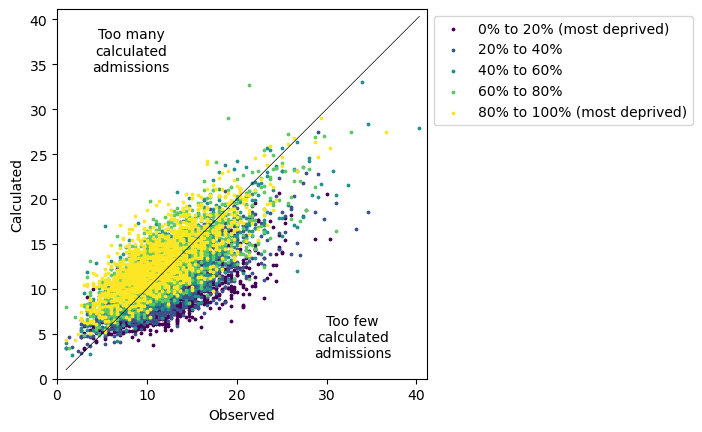

In [66]:
fig, ax = plt.subplots()
# Equality line:
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(df_here['admissions'], df_here['admissions_from_ssnap_props'], s=3, color=colours[q], label=dict_labels[qmin])

# Labels:
ax.set_xlabel('Observed')
ax.set_ylabel('Calculated')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
# Annotate which parts of the graph mean too high/low admissions:
ax.annotate('Too many\ncalculated\nadmissions', xy=(0.2, 0.95), ha='center', va='top', xycoords='axes fraction')
ax.annotate('Too few\ncalculated\nadmissions', xy=(0.8, 0.05), ha='center', va='bottom', xycoords='axes fraction')
# Sizing:
ax.set_xlim(0.0, zmax*1.02)
ax.set_ylim(0.0, zmax*1.02)
ax.set_aspect('equal')
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs.png', bbox_inches='tight')
plt.show()

Admissions are under-predicted for lowest quantile (most deprived) and over-predicted for highest quantile (least deprived).

Make a similar figure with the same data but each deprivation quantile on its own axis:

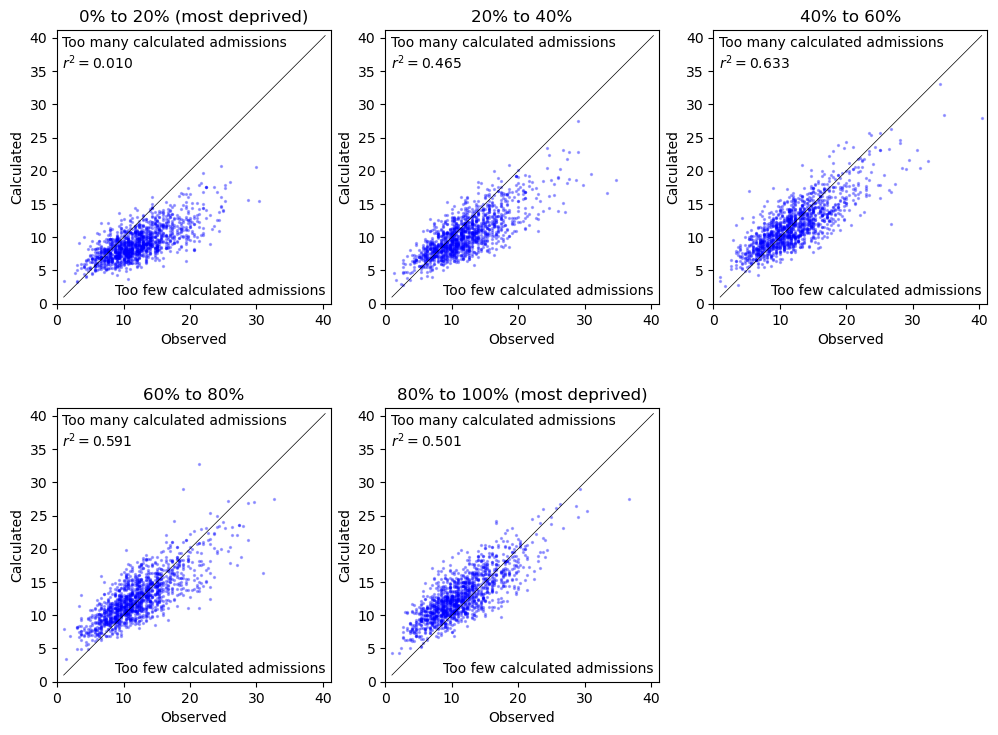

In [81]:
ncols=3
nrows=2
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9))

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    ax = axs[q // ncols, q % ncols]
    # Equality line:
    ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)
    
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(
        df_here['admissions'],
        df_here['admissions_from_ssnap_props'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.3
    )
    
    # Labels:
    ax.set_xlabel('Observed')
    ax.set_ylabel('Calculated')
    ax.set_title(dict_labels[qmin])
    # Annotate r-squared value:
    r2_key = f'r2_q{qmin:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    ax.annotate('Too many calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate('Too few calculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_xlim(0.0, zmax*1.02)
    ax.set_ylim(0.0, zmax*1.02)
    ax.set_aspect('equal')

axs[-1, -1].set_visible(False)
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs_separate.png', bbox_inches='tight')
plt.show()